# 손 X-ray 골연령 예측 — **InceptionV3 + Bilinear Pooling** · v3
### (v2 = 논문 §3.7 동일 구현 → 여기에 크롭 수정 + 과적합 대책을 얹은 버전)

> Zhang, Wu, Zhou & Li, *Uncertainty-aware multi-stream deep learning for pediatric bone age assessment* (JKSU-CIS, 2026) — **최종 채택 모델(MAE 4.10개월)**

## 모델 구조는 논문 그대로입니다 (v2와 동일, 변경 없음)
식 30~36: InceptionV3(top 제거) → **순수 1×1 conv 2048→512→128** → bilinear pooling(16,384) → 성별 임베딩 16 concat → 선형회귀 1.

## v3에서 바뀐 것 — 두 갈래

**① 전처리 (기본값 변경, 논문 표8의 "automatic bounding box cropping"을 더 견고하게 구현)**
- `CROP_MODE="auto"` : 번인 라벨(L/R/CLT)을 손으로 오인하던 문제 해결. 백분위 클리핑 → 다중 임계 후보 → 손다움 게이트 → 실패 시 원본 반환.
- 전수 QC 로그(`crop_qc.csv`) + **의심 케이스 컨택트 시트(1-2 셀)**.
- `CROP_MODE="paper"`로 두면 v2의 단순 bbox 크롭으로 즉시 복귀합니다.

**② 학습 레시피 (`REG_PROFILE` 한 줄로 전환)**

| 항목 | `"paper"` (논문 기준선 = v2) | `"regularized"` (v3 기본, 과적합 억제) |
|---|---|---|
| bilinear 정규화 | OFF | **ON** (signed-sqrt+ℓ2 — 논문도 실험, MAE차 ≤0.02개월이라 정합) |
| dropout | 0.0 | **0.3** (논문 미언급) |
| LR (백본/헤드) | 1e-4 / 1e-4 | **5e-5 / 5e-4** |
| weight decay | 1e-5 | **1e-4 / 1e-3** |
| 증강 | 없음 | **medium** (좌우반전·회전20°·affine·밝기대비) |
| BN | 학습 | **고정**(배치 16 대응) |

> **논문 재현이 목적이면** `CROP_MODE="paper"` + `REG_PROFILE="paper"` → v2와 동일합니다.
> **성능이 목적이면** 기본값(`auto` + `regularized`)으로 두고, 갭이 벌어지면 항목을 하나씩만 조정하세요.

## 실행 순서
PART 0 → PART 1 (전처리 + **1-2 크롭 QC 반드시 확인**) → PART 2 → PART 3 → PART 4
캐시·체크포인트는 `{크롭모드}_{해상도}` 폴더로 분리되어 설정을 바꿔도 이전 결과와 섞이지 않습니다.


---
# PART 0 · 공통 셋업  *(항상 먼저 실행 — 전부 정의/로드, 무거운 연산 없음)*

### 0-1. 환경 확인

In [1]:
import os, sys, json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from tqdm.auto import tqdm

print("Python     :", sys.version.split()[0])
print("PyTorch    :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     :", device)

# [주의] RTX 5060(Blackwell, sm_120)은 최신 PyTorch 필요.
# CUDA=False 이거나 'no kernel image' 오류 시 CUDA 12.8+ 빌드 설치:
#   pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

Python     : 3.11.9
PyTorch    : 2.12.0.dev20260408+cu128
torchvision: 0.27.0.dev20260407+cu128
CUDA avail : True
GPU        : NVIDIA GeForce RTX 5060 Laptop GPU | CUDA 12.8
device     : cuda


### 0-2. 시드 & 한글 경로 로더

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

def imread_kr(path, flags=cv2.IMREAD_GRAYSCALE):
    '''한글/유니코드 경로에서도 동작하는 이미지 로드. 실패 시 None.'''
    try:
        data = np.fromfile(str(path), dtype=np.uint8)
        return cv2.imdecode(data, flags)
    except Exception:
        return None

def imwrite_kr(path, img):
    '''한글/유니코드 경로에도 저장 가능한 이미지 쓰기.'''
    path = str(path); ext = os.path.splitext(path)[1] or ".png"
    ok, buf = cv2.imencode(ext, img)
    if ok: buf.tofile(path)
    return ok

### 0-3. 경로 설정 & 전처리 파라미터
**`BASE_DIR` 한 줄만** 본인 경로로 수정하세요. `IMG_SIZE`는 전처리(캐시)와 직결되므로 여기 둡니다 — 바꾸면 캐시를 다시 만들어야 합니다.

In [3]:
# ── 경로: 여기만 수정 ───────────────────────────────────────────────
BASE_DIR = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터")   # ← 수정

TRAIN_IMG_DIR = BASE_DIR / "Bone+Age+Training+Set" / "boneage-training-dataset"
TRAIN_CSV     = BASE_DIR / "Bone+Age+Training+Set+Annotations" / "train.csv"
VAL_IMG_DIR   = BASE_DIR / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "boneage-validation-dataset-1"
VAL_CSV       = BASE_DIR / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "Validation Dataset.csv"

# ── 전처리 스위치 (캐시와 직결 — 바꾸면 PART 1이 새로 만듭니다) ──────
IMG_SIZE  = 480          # 논문 InceptionV3 단일스트림 입력
CROP_MODE = "auto"       # "auto"  : 손다움 게이트 크롭 (라벨/프레임 오인식 방지)  ★권장
                         # "paper" : 논문 표8식 단순 bbox (재현 기준선)
                         # "plate" : 2단계 크롭 (라벨 오인식 발생 — 비교용)

# 캐시·체크포인트는 (크롭모드 × 해상도)별로 분리 → 설정을 바꿔도 섞이지 않음
TAG       = f"{CROP_MODE}_{IMG_SIZE}"
CACHE_DIR = BASE_DIR / "cache_preprocessed" / TAG
CKPT_DIR  = BASE_DIR / "checkpoints" / TAG
for d in (CACHE_DIR, CACHE_DIR/"train", CACHE_DIR/"val", CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

BEST_CKPT    = CKPT_DIR / "best.pt"
LAST_CKPT    = CKPT_DIR / "last.pt"
HISTORY_JSON = CKPT_DIR / "history.json"
DONE_MARKER  = CACHE_DIR / "_DONE.json"
QC_CSV       = CACHE_DIR / "crop_qc.csv"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
print(f"BASE_DIR : {BASE_DIR}")
print(f"IMG_SIZE : {IMG_SIZE} | CROP_MODE: {CROP_MODE}")
print(f"CACHE    : {CACHE_DIR}")
print(f"CKPT     : {CKPT_DIR}")


BASE_DIR : C:\Users\Win11Pro\Desktop\뼈데이터
IMG_SIZE : 480 | CROP_MODE: auto
CACHE    : C:\Users\Win11Pro\Desktop\뼈데이터\cache_preprocessed\auto_480
CKPT     : C:\Users\Win11Pro\Desktop\뼈데이터\checkpoints\auto_480


### 0-4. 라벨 로드 (CSV) & 타깃 통계

In [4]:
def load_labels(csv_path, img_dir):
    '''id/boneage/male 컬럼을 유연하게 탐지해 표준 DataFrame으로 반환.'''
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}
    def pick(keys):
        for k in keys:
            for lc, orig in cols.items():
                if k in lc: return orig
        return None
    id_col  = pick(["id", "case", "image"]) or df.columns[0]
    age_col = pick(["boneage", "bone age", "age"])
    sex_col = pick(["male", "sex", "gender"])
    assert age_col and sex_col, f"컬럼 탐지 실패: {list(df.columns)}"
    out = pd.DataFrame()
    out["id"]      = df[id_col].astype(str).str.replace(".png","",regex=False).str.strip()
    out["boneage"] = pd.to_numeric(df[age_col], errors="coerce")
    s = df[sex_col]
    if s.dtype == bool:
        male = s.astype(int)
    else:
        sv = s.astype(str).str.lower().str.strip()
        male = sv.map({"true":1,"false":0,"m":1,"f":0,"male":1,"female":0,"1":1,"0":0})
        if male.isna().any(): male = pd.to_numeric(s, errors="coerce")
    out["male"] = male.astype(float)
    out["path"] = out["id"].apply(lambda i: str(Path(img_dir)/f"{i}.png"))
    return out.dropna(subset=["boneage","male"]).reset_index(drop=True)

train_df = load_labels(TRAIN_CSV, TRAIN_IMG_DIR)
val_df   = load_labels(VAL_CSV,   VAL_IMG_DIR)
AGE_MEAN = float(train_df.boneage.mean())     # 회귀 안정화용(가정): 학습셋 통계
AGE_STD  = float(train_df.boneage.std())
print(f"학습 {len(train_df):,} · 검증 {len(val_df):,} | 나이 {AGE_MEAN:.2f}±{AGE_STD:.2f} | 남 {train_df.male.mean():.1%}")

학습 12,611 · 검증 1,425 | 나이 127.32±41.18 | 남 54.2%


### 0-5. 전처리 (논문 표 8: ① 흑백+자동 크롭 → ② 리사이즈 → ③ 히스토그램 평활화)

**크롭이 라벨(L/R/CLT 등)을 손으로 오인하는 문제**를 잡는 것이 이번 수정의 핵심입니다. 원인은 3가지입니다.

| 원인 | 설명 | 대응 |
|---|---|---|
| 번인 라벨의 **포화(255)** | 밝기 255 라벨이 Otsu 임계를 위로 끌어올려, 중간 밝기의 손이 임계 아래로 떨어짐 → 마스크에 라벨만 남음 | ① **백분위(1~99%) 클리핑** 후 임계 계산 |
| **단일 임계 의존** | 한 번의 Otsu가 실패하면 그대로 실패 | ② **다중 임계 후보**(Otsu·0.8·0.6·백분위 65/50)를 순차 시도 |
| **면적만으로 선택** | 라벨 블록이 2%를 넘으면 그대로 "가장 큰 blob"이 됨 | ③ **손다움 게이트**: 면적 비율, 포화 픽셀 비율(라벨은 거의 전부 255), 종횡비(손은 세로로 김), 중심 위치(라벨은 가장자리) |

추가로 **반전 영상**(밝은 배경 + 어두운 손)은 전경 비율이 과반이면 마스크를 자동 반전해 처리하고, 모든 후보가 실패하면 **원본 그대로 반환 + `crop_qc.csv`에 실패로 기록**합니다(조용히 잘못 자르는 것보다 낫습니다).


In [5]:
# ─────────────────────────────────────────────────────────────────────
# (A) 손다움 게이트 크롭  ★기본값 (CROP_MODE="auto")
# ─────────────────────────────────────────────────────────────────────
def _norm_clip(g, lo=1.0, hi=99.0):
    """포화된 번인 라벨(255)이 Otsu 임계를 끌어올리는 것을 막는 백분위 클리핑."""
    a, b = np.percentile(g, lo), np.percentile(g, hi)
    if b - a < 1e-3: return g.copy()
    return np.clip((g.astype(np.float32) - a) * (255.0 / (b - a)), 0, 255).astype(np.uint8)

def _mask_at(gsm, thr, k):
    _, m = cv2.threshold(gsm, thr, 255, cv2.THRESH_BINARY)
    if m.mean() > 0.5 * 255:                        # 전경이 과반 → 반전 영상 보정
        m = 255 - m
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  np.ones((max(3, k//3) | 1,)*2, np.uint8))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((k, k), np.uint8))
    return m

def _hand_score(st, gsm, lab, idx, H, W, min_area):
    """손이면 점수, 라벨/프레임/잡티면 None. 게이트를 통과한 것만 후보."""
    x, y, w, h, area = st
    ar = area / (H * W)
    if ar < min_area or ar > 0.90:             return None   # 게이트1 면적
    if w > 0.97 * W and h > 0.97 * H:          return None   # 게이트2 프레임 전체
    px = gsm[lab == idx]
    if px.size and (px >= 250).mean() > 0.8:   return None   # 게이트3 포화 라벨
    aspect = h / max(w, 1)
    if aspect < 0.6 or aspect > 4.5:           return None   # 게이트4 손은 세로로 김
    extent = area / max(w * h, 1)
    cx, cy = (x + w/2) / W, (y + h/2) / H
    center_pen = abs(cx - 0.5) + 0.5 * abs(cy - 0.5)         # 라벨은 가장자리·코너
    return ar - 0.6 * center_pen + 0.2 * (1 - abs(extent - 0.55))

def crop_hand_auto(gray, pad_ratio=0.04, work=512, return_info=False):
    """① 백분위 클리핑 ② 다중 임계 후보 ③ 손다움 게이트 ④ 실패 시 원본 반환(+사유)."""
    H0, W0 = gray.shape
    s   = work / max(H0, W0)
    gsm = cv2.resize(gray, (max(1, int(W0*s)), max(1, int(H0*s))),
                     interpolation=cv2.INTER_AREA) if s < 1 else gray.copy()
    gsm = cv2.GaussianBlur(_norm_clip(gsm), (5, 5), 0)
    H, W = gsm.shape
    k = max(5, int(min(H, W) * 0.03) | 1)

    otsu, _ = cv2.threshold(gsm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cands = [otsu, otsu*0.8, otsu*0.6, np.percentile(gsm, 65), np.percentile(gsm, 50)]
    best = None
    for min_area in (0.02, 0.008):                  # 1차 일반 → 2차 유아 등 작은 손 완화
        for thr in cands:
            m = _mask_at(gsm, float(thr), k)
            n, lab, stats, _ = cv2.connectedComponentsWithStats(m, 8)
            for i in range(1, n):
                sc = _hand_score(stats[i], gsm, lab, i, H, W, min_area)
                if sc is not None and (best is None or sc > best[0]):
                    best = (sc, stats[i], float(thr))
            if best is not None: break
        if best is not None: break

    if best is None:
        info = dict(ok=False, reason="no_valid_blob", area_ratio=0.0, aspect=0.0, cx=0.0, cy=0.0)
        return (gray, info) if return_info else gray

    sc, (x, y, w, h, area), thr = best
    inv = 1.0 / s if s < 1 else 1.0
    X, Y, Wc, Hc = [int(v * inv) for v in (x, y, w, h)]
    px_, py_ = int(Wc * pad_ratio), int(Hc * pad_ratio)
    roi = gray[max(0, Y-py_):min(H0, Y+Hc+py_), max(0, X-px_):min(W0, X+Wc+px_)]
    if roi.size == 0:
        info = dict(ok=False, reason="empty_roi", area_ratio=0.0, aspect=0.0, cx=0.0, cy=0.0)
        return (gray, info) if return_info else gray
    info = dict(ok=True, reason="", score=float(sc), area_ratio=float(area/(H*W)),
                aspect=float(Hc/max(Wc, 1)), extent=float(area/max(w*h, 1)),
                cx=float((x+w/2)/W), cy=float((y+h/2)/H))
    return (roi, info) if return_info else roi


# ─────────────────────────────────────────────────────────────────────
# (B) 논문 표8식 단순 bbox 크롭  (CROP_MODE="paper")
# ─────────────────────────────────────────────────────────────────────
def crop_hand_paper(gray, pad_ratio=0.03):
    H, W = gray.shape
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    k  = max(3, int(min(H, W) * 0.02) | 1); ks = max(3, (k // 3) | 1)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  np.ones((ks, ks), np.uint8))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((k, k),  np.uint8))
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return gray
    x, y, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    px, py = int(w * pad_ratio), int(h * pad_ratio)
    roi = gray[max(0, y-py):min(H, y+h+py), max(0, x-px):min(W, x+w+px)]
    return roi if roi.size else gray


# ─────────────────────────────────────────────────────────────────────
# (C) 기존 2단계 크롭 (라벨 오인식 발생 — 비교용으로만 보존)
# ─────────────────────────────────────────────────────────────────────
def crop_hand_roi(gray, pad_ratio=0.03):
    H, W = gray.shape
    _, lit = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    lit = cv2.morphologyEx(lit, cv2.MORPH_OPEN, np.ones((15, 15), np.uint8))
    cnts, _ = cv2.findContours(lit, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    g_in = gray
    if cnts:
        px, py, pw, ph = cv2.boundingRect(max(cnts, key=cv2.contourArea))
        if pw * ph > 0.15 * H * W: g_in = gray[py:py+ph, px:px+pw]
    Hi, Wi = g_in.shape
    blur = cv2.GaussianBlur(g_in, (7, 7), 0)
    _, hand = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hand = cv2.morphologyEx(hand, cv2.MORPH_OPEN,  np.ones((5, 5),   np.uint8))
    hand = cv2.morphologyEx(hand, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
    n, _, stats, _ = cv2.connectedComponentsWithStats(hand, 8)
    best_i, best_area = -1, 0
    for i in range(1, n):
        x, y, w, h, area = stats[i]
        if w > 0.97 * Wi and h > 0.97 * Hi: continue
        if area < 0.02 * Hi * Wi: continue
        if area > best_area: best_area, best_i = area, i
    if best_i < 0: return g_in
    x, y, w, h, _ = stats[best_i]
    px_, py_ = int(w * pad_ratio), int(h * pad_ratio)
    roi = g_in[max(0, y-py_):min(Hi, y+h+py_), max(0, x-px_):min(Wi, x+w+px_)]
    return roi if roi.size else g_in


CROP_FN = {"auto": crop_hand_auto, "paper": crop_hand_paper, "plate": crop_hand_roi}

def preprocess(gray, size=None, mode=None, return_info=False):
    """논문 표8 3단계 → size×size uint8."""
    size, mode = size or IMG_SIZE, mode or CROP_MODE
    if mode == "auto":
        roi, info = crop_hand_auto(gray, return_info=True)
    else:
        roi, info = CROP_FN[mode](gray), dict(ok=True, reason="")
    out = cv2.equalizeHist(cv2.resize(roi, (size, size), interpolation=cv2.INTER_AREA))
    return (out, info) if return_info else out

print("전처리 준비 완료 | CROP_MODE =", CROP_MODE)


전처리 준비 완료 | CROP_MODE = auto


### 0-6. Dataset · Transform · 모델 · 헬퍼 정의

In [6]:
# ── 증강 팩토리 (실제 적용 여부는 PART 2의 REG_PROFILE이 결정) ─────────
# RSNA에는 우수(右手)·양손 이미지가 섞여 있어 좌우 반전은 데이터 정합에도 도움이 됩니다.
_AUG = {
    "light":  [transforms.RandomRotation(15),
               transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.95, 1.05))],
    "medium": [transforms.RandomHorizontalFlip(0.5),
               transforms.RandomRotation(20),
               transforms.RandomAffine(0, translate=(0.08, 0.08), scale=(0.90, 1.10), shear=5),
               transforms.ColorJitter(brightness=0.20, contrast=0.20)],
    "strong": [transforms.RandomHorizontalFlip(0.5),
               transforms.RandomRotation(25),
               transforms.RandomAffine(0, translate=(0.10, 0.10), scale=(0.85, 1.15), shear=8),
               transforms.ColorJitter(brightness=0.30, contrast=0.30),
               transforms.RandomErasing(p=0.25, scale=(0.02, 0.10))],   # ToTensor 뒤 적용
}
_PRE  = [transforms.ToPILImage()]
_POST = [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]

def make_train_tf(use_aug=False, strength="medium"):
    aug  = _AUG[strength] if use_aug else []
    geom = [t for t in aug if not isinstance(t, transforms.RandomErasing)]
    tens = [t for t in aug if isinstance(t, transforms.RandomErasing)]
    return transforms.Compose(_PRE + geom + _POST + tens)

eval_tf  = transforms.Compose(_PRE + _POST)
train_tf = make_train_tf(False)     # 기본값(논문 기준선). PART 2에서 프로파일대로 재생성됩니다.

class BoneAgeDataset(Dataset):
    def __init__(self, df, split, tf):
        self.df, self.split, self.tf = df.reset_index(drop=True), split, tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        g = imread_kr(CACHE_DIR/self.split/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
        x = self.tf(np.stack([g, g, g], -1))                    # 흑백 → 3채널
        gender  = torch.tensor([r["male"]], dtype=torch.float32)
        y_norm  = torch.tensor([(r["boneage"]-AGE_MEAN)/AGE_STD], dtype=torch.float32)
        y_month = torch.tensor([r["boneage"]], dtype=torch.float32)
        return x, gender, y_norm, y_month


In [7]:
class InceptionV3Bilinear(nn.Module):
    """논문 §3.7 식 30~36 그대로.
       - 식31: 1×1 conv 2개(2048→512→128), BatchNorm/ReLU 없음 = 순수 pointwise 투영
       - 식32~33: B = XᵀX/(hw) → flatten(128² = 16,384)
       - 식34~36: 성별 임베딩 k=16 concat → 선형회귀
       옵션 2개(논문 정합):
       - bilinear_norm : signed-sqrt + ℓ2. 논문도 실험했고 MAE 차 ≤0.02개월 → 켜도 정합.
       - dropout       : 논문 미언급(0.0이면 논문 그대로). 과적합 억제용.
       외적은 값을 제곱하므로 AMP(fp16) 오버플로 방지를 위해 fp32로 강제합니다."""
    def __init__(self, reduce1=512, reduce2=128, gender_dim=16, dropout=0.0,
                 pretrained=True, freeze=False, bilinear_norm=False):
        super().__init__()
        self.bilinear_norm = bilinear_norm
        weights = Inception_V3_Weights.IMAGENET1K_V1 if pretrained else None
        net = inception_v3(weights=weights, aux_logits=True)
        net.transform_input = False
        self.backbone = create_feature_extractor(net, return_nodes={"Mixed_7c": "feat"})
        if freeze:
            for p in self.backbone.parameters(): p.requires_grad = False
        self.reduce = nn.Sequential(                                  # 식 31
            nn.Conv2d(2048, reduce1, 1),                              # 2048 → 512
            nn.Conv2d(reduce1, reduce2, 1),                           # 512  → 128
        )
        self.drop      = nn.Dropout(dropout)
        self.gender_fc = nn.Linear(1, gender_dim)                     # 식 34
        self.regressor = nn.Linear(reduce2*reduce2 + gender_dim, 1)   # 식 35~36

    def bilinear_pool(self, f2):                                      # 식 32~33
        with torch.autocast(device_type="cuda", enabled=False):       # fp32 강제
            f2 = f2.float()
            B, C, H, W = f2.shape
            X = f2.view(B, C, H*W)
            z = torch.bmm(X, X.transpose(1, 2)).view(B, C*C) / (H*W)
            if self.bilinear_norm:
                z = torch.sign(z) * torch.sqrt(torch.abs(z) + 1e-8)
                z = F.normalize(z, dim=1)
        return z

    def forward(self, x, gender):
        f2 = self.reduce(self.backbone(x)["feat"])
        z  = self.drop(self.bilinear_pool(f2))
        u  = torch.cat([z, self.gender_fc(gender).float()], dim=1)    # 식 35
        return self.regressor(u).squeeze(1)                           # 식 36


In [8]:
def build_model(arch, pretrained=False, freeze=False):
    return InceptionV3Bilinear(
        reduce1=arch["REDUCE_1"], reduce2=arch["REDUCE_2"],
        gender_dim=arch["GENDER_EMB_DIM"], dropout=arch.get("DROPOUT", 0.0),
        pretrained=pretrained, freeze=freeze,
        bilinear_norm=arch["BILINEAR_NORM"]).to(device)

def mae_months(pred_norm, y_month, mean, std):
    pm = pred_norm.detach().float().cpu() * std + mean
    return (pm - y_month.cpu().squeeze(1)).abs().sum().item()

@torch.no_grad()
def evaluate(model, loader, mean, std, use_amp=True):
    model.eval(); tot, n = 0.0, 0
    for x, g, yn, ym in loader:
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=use_amp):
            pred = model(x, g)
        tot += mae_months(pred, ym, mean, std); n += x.size(0)
    return tot / n

def save_checkpoint(path, model, arch, mean, std, optimizer=None, scheduler=None,
                    scaler=None, epoch=None, best_val=None, history=None, no_improve=None):
    ck = {"model": model.state_dict(), "arch": arch, "age_mean": mean, "age_std": std}
    if optimizer  is not None: ck["optimizer"]  = optimizer.state_dict()
    if scheduler  is not None: ck["scheduler"]  = scheduler.state_dict()
    if scaler     is not None: ck["scaler"]     = scaler.state_dict()
    if epoch      is not None: ck["epoch"]      = epoch
    if best_val   is not None: ck["best_val"]   = best_val
    if history    is not None: ck["history"]    = history
    if no_improve is not None: ck["no_improve"] = no_improve
    torch.save(ck, path)

print("정의 완료: Dataset · InceptionV3Bilinear · build_model · evaluate · save_checkpoint")


정의 완료: Dataset · InceptionV3Bilinear · build_model · evaluate · save_checkpoint


---
# PART 1 · 전처리 → 캐시 저장  *(1회만; 완료 표식 있으면 자동 스킵)*

In [9]:
FORCE_REBUILD = False   # 전처리를 강제로 다시 만들려면 True

def cache_is_valid():
    if FORCE_REBUILD or not DONE_MARKER.exists(): return False
    info = json.load(open(DONE_MARKER, encoding="utf-8"))
    return info.get("img_size") == IMG_SIZE and info.get("crop_mode") == CROP_MODE

def build_cache(df, split):
    """전처리 + 크롭 QC 로그(crop_qc.csv)를 함께 생성."""
    out_dir = CACHE_DIR / split; made = skipped = failed = 0; rows = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"cache/{split}"):
        dst = out_dir / f"{r['id']}.png"
        if dst.exists() and not FORCE_REBUILD: skipped += 1; continue
        g = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
        if g is None: failed += 1; continue
        out, info = preprocess(g, return_info=True)
        imwrite_kr(dst, out); made += 1
        rows.append(dict(split=split, id=r["id"], ok=info.get("ok", True),
                         reason=info.get("reason", ""), area_ratio=info.get("area_ratio", np.nan),
                         aspect=info.get("aspect", np.nan), cx=info.get("cx", np.nan),
                         cy=info.get("cy", np.nan)))
    print(f"[{split}] 생성 {made} · 스킵 {skipped} · 실패 {failed}")
    return pd.DataFrame(rows)

if cache_is_valid():
    print(f"캐시 유효 ({CROP_MODE}/{IMG_SIZE}) — 건너뜀 (다시 만들려면 FORCE_REBUILD=True)")
else:
    qc = pd.concat([build_cache(train_df, "train"), build_cache(val_df, "val")], ignore_index=True)
    if len(qc): qc.to_csv(QC_CSV, index=False, encoding="utf-8-sig")
    json.dump({"img_size": IMG_SIZE, "crop_mode": CROP_MODE,
               "train": len(train_df), "val": len(val_df)},
              open(DONE_MARKER, "w", encoding="utf-8"))
    print("전처리 완료 · QC 로그:", QC_CSV)

def filter_cached(df, split):
    ok = df["id"].apply(lambda i: (CACHE_DIR/split/f"{i}.png").exists())
    return df[ok].reset_index(drop=True)
train_df = filter_cached(train_df, "train")
val_df   = filter_cached(val_df,   "val")
print(f"사용 가능: 학습 {len(train_df):,} · 검증 {len(val_df):,}")


cache/train:   0%|          | 0/12611 [00:00<?, ?it/s]

[train] 생성 12611 · 스킵 0 · 실패 0


cache/val:   0%|          | 0/1425 [00:00<?, ?it/s]

[val] 생성 1425 · 스킵 0 · 실패 0
전처리 완료 · QC 로그: C:\Users\Win11Pro\Desktop\뼈데이터\cache_preprocessed\auto_480\crop_qc.csv
사용 가능: 학습 12,611 · 검증 1,425


### 1-1. 전/후 정성 비교 (논문 그림 9→10)


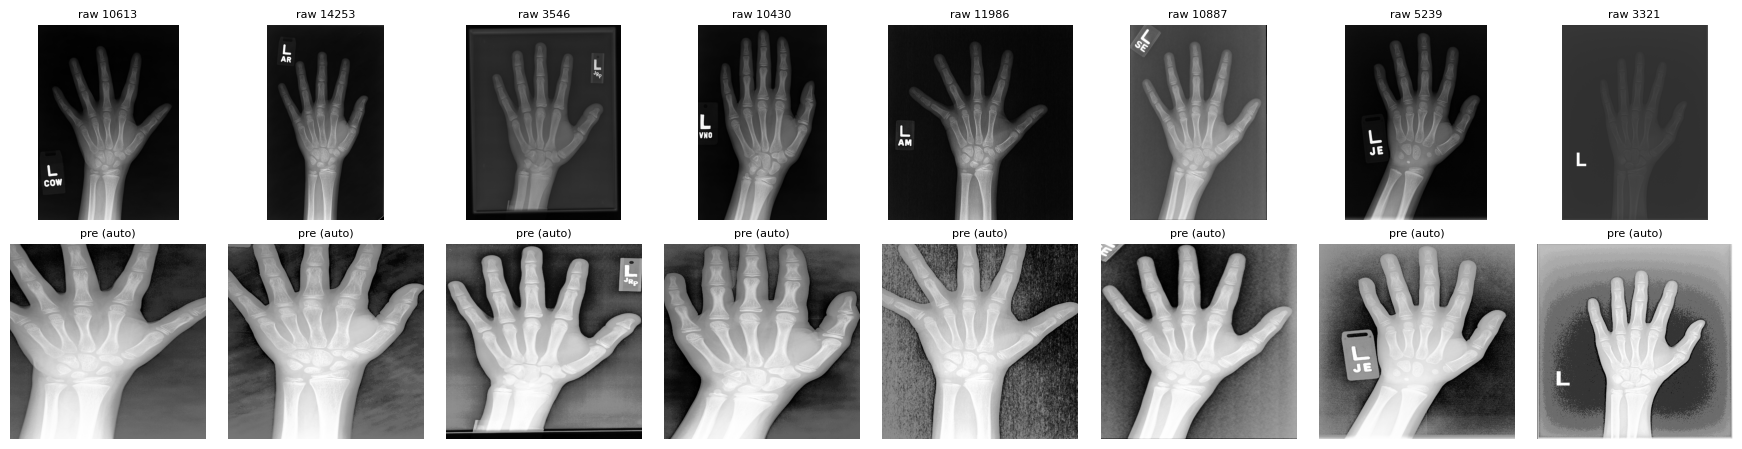

In [10]:
N_QC, QC_SEED = 8, SEED
sample = train_df.sample(N_QC, random_state=QC_SEED)
cols = min(8, N_QC); rows = int(np.ceil(N_QC/cols))
fig, axes = plt.subplots(rows*2, cols, figsize=(2.2*cols, 4.6*rows)); axes = np.atleast_2d(axes)
for j, (_, r) in enumerate(sample.iterrows()):
    rr, cc = (j//cols)*2, j % cols
    raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
    pre = imread_kr(CACHE_DIR/"train"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    axes[rr,   cc].imshow(raw, cmap="gray"); axes[rr,   cc].set_title(f"raw {r['id']}", fontsize=8)
    axes[rr+1, cc].imshow(pre, cmap="gray"); axes[rr+1, cc].set_title(f"pre ({CROP_MODE})", fontsize=8)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()


### 1-2. 🔎 크롭 QC — 의심 케이스만 골라 보기 *(학습 전 필수)*
`crop_qc.csv`에는 이미지마다 크롭 성공 여부와 **면적비 / 종횡비 / 중심좌표**가 기록됩니다. 라벨을 잘못 잡으면 거의 항상 **면적비가 매우 작거나(<3%) 중심이 가장자리로 치우칩니다.** 아래 셀은 그런 케이스만 뽑아 보여줍니다 — 여기서 손이 제대로 잡혔는지 확인한 뒤에 학습으로 넘어가세요.


전체 14,036 | 크롭 실패 533 · 과소면적 1130 · 가장자리중심 1034 · 비율이상 600
→ 의심 케이스 1197건 (8.53%)


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_20064\2867682757.py:24: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_20064\2867682757.py:24: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


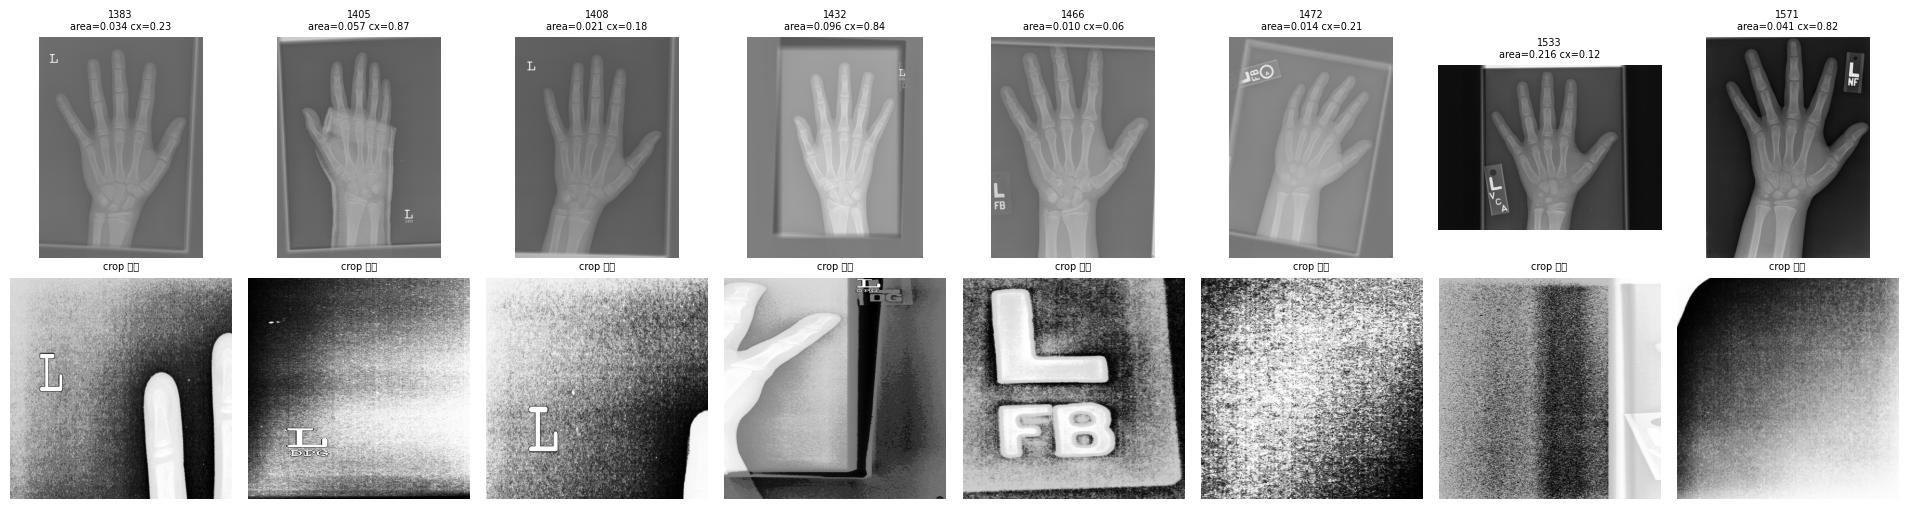

의심 목록 저장: C:\Users\Win11Pro\Desktop\뼈데이터\cache_preprocessed\auto_480\crop_suspect.csv


In [11]:
qc = pd.read_csv(QC_CSV) if QC_CSV.exists() else pd.DataFrame()
if len(qc) == 0:
    print("QC 로그 없음 — FORCE_REBUILD=True 로 PART 1을 다시 실행하면 생성됩니다.")
else:
    fail = ~qc["ok"].astype(bool)
    tiny = qc["area_ratio"] < 0.03                      # 손이라기엔 너무 작음 (라벨 의심)
    edge = (qc["cx"] - 0.5).abs() > 0.30                # 중심이 좌우 가장자리 (라벨 의심)
    thin = (qc["aspect"] < 0.8) | (qc["aspect"] > 4.0)  # 손 비율에서 벗어남
    sus  = qc[fail | tiny | edge | thin]
    print(f"전체 {len(qc):,} | 크롭 실패 {fail.sum()} · 과소면적 {tiny.sum()} · 가장자리중심 {edge.sum()} · 비율이상 {thin.sum()}")
    print(f"→ 의심 케이스 {len(sus)}건 ({len(sus)/len(qc)*100:.2f}%)")
    if len(sus):
        show = sus.head(8)
        fig, axes = plt.subplots(2, len(show), figsize=(2.4*len(show), 5.2)); axes = np.atleast_2d(axes)
        for j, (_, r) in enumerate(show.iterrows()):
            src = TRAIN_IMG_DIR if r["split"] == "train" else VAL_IMG_DIR
            raw = imread_kr(Path(src)/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
            pre = imread_kr(CACHE_DIR/r["split"]/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
            if raw is not None: axes[0, j].imshow(raw, cmap="gray")
            if pre is not None: axes[1, j].imshow(pre, cmap="gray")
            axes[0, j].set_title(f"{r['id']}\narea={r['area_ratio']:.3f} cx={r['cx']:.2f}", fontsize=7)
            axes[1, j].set_title("crop 결과", fontsize=7)
        for ax in axes.ravel(): ax.axis("off")
        plt.tight_layout(); plt.show()
        sus.to_csv(CACHE_DIR/"crop_suspect.csv", index=False, encoding="utf-8-sig")
        print("의심 목록 저장:", CACHE_DIR/"crop_suspect.csv")
    else:
        print("✅ 의심 케이스 없음 — 학습으로 진행해도 됩니다.")


---
# PART 2 · 학습 설정 ⚙️  *(하이퍼파라미터를 여기서 바꾸고, 이 파트부터 아래로 재실행)*

In [12]:
# ═══ 학습 프로파일 ══════════════════════════════════════════════════
# "paper"       : 논문 기준선 (증강 없음·정규화 최소 → 논문 재현용)
# "regularized" : 과적합 억제 (v3 권장 — 아래 표의 항목만 논문과 다름)
REG_PROFILE = "regularized"

PRESET = {
    "paper": dict(
        LR_BACKBONE=1e-4, LR_HEAD=1e-4, WD_BACKBONE=1e-5, WD_HEAD=1e-5,
        DROPOUT=0.0, BILINEAR_NORM=False, FREEZE_BN=False,
        USE_AUG=False, AUG_STRENGTH="light",
    ),
    "regularized": dict(
        LR_BACKBONE=5e-5,   # 백본은 낮게 → 사전학습 특징 보존
        LR_HEAD=5e-4,       # 새로 배우는 1×1 투영 + 회귀 헤드는 높게
        WD_BACKBONE=1e-4, WD_HEAD=1e-3,
        DROPOUT=0.3,        # 16,384차원 bilinear 특징에 dropout
        BILINEAR_NORM=True, # signed-sqrt + ℓ2 (논문도 실험, MAE 차 ≤0.02개월)
        FREEZE_BN=True,     # 배치 16에서 BN 통계 흔들림 방지
        USE_AUG=True, AUG_STRENGTH="medium",
    ),
}
globals().update(PRESET[REG_PROFILE])

# ── 공통 하이퍼파라미터 ──────────────────────────────────────────────
BATCH_SIZE     = 16
EPOCHS         = 100
FREEZE_BACKBONE= False
GENDER_EMB_DIM = 16
REDUCE_1, REDUCE_2 = 512, 128
NUM_WORKERS    = 0        # Windows+Jupyter 안전값
USE_AMP        = True     # bilinear는 내부에서 fp32 강제 → 안전
RESUME         = False
EARLY_STOP_PATIENCE = 15
MIN_DELTA           = 0.01
# ─────────────────────────────────────────────────────────────────────

ARCH = {"REDUCE_1": REDUCE_1, "REDUCE_2": REDUCE_2, "GENDER_EMB_DIM": GENDER_EMB_DIM,
        "BILINEAR_NORM": BILINEAR_NORM, "DROPOUT": DROPOUT, "IMG_SIZE": IMG_SIZE,
        "CROP_MODE": CROP_MODE, "REG_PROFILE": REG_PROFILE,
        "USE_AUG": USE_AUG, "AUG_STRENGTH": AUG_STRENGTH}
print(f"프로파일: {REG_PROFILE}")
print(f"  lr(bb/head) {LR_BACKBONE}/{LR_HEAD} · wd(bb/head) {WD_BACKBONE}/{WD_HEAD}")
print(f"  dropout {DROPOUT} · bilinear_norm {BILINEAR_NORM} · freeze_bn {FREEZE_BN}")
print(f"  aug {USE_AUG} ({AUG_STRENGTH}) · crop {CROP_MODE} · img {IMG_SIZE}")


프로파일: regularized
  lr(bb/head) 5e-05/0.0005 · wd(bb/head) 0.0001/0.001
  dropout 0.3 · bilinear_norm True · freeze_bn True
  aug True (medium) · crop auto · img 480


In [13]:
# 증강을 프로파일대로 재구성한 뒤 데이터로더 생성
train_tf = make_train_tf(USE_AUG, AUG_STRENGTH)
print("train 증강:", f"ON ({AUG_STRENGTH})" if USE_AUG else "OFF (논문 기준선)")

train_loader = DataLoader(BoneAgeDataset(train_df, "train", train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print("배치 수: train", len(train_loader), "| val", len(val_loader))


train 증강: ON (medium)
배치 수: train 788 | val 90


In [14]:
# 모델 · 옵티마이저(파라미터 그룹 분리) · 스케줄러
model = build_model(ARCH, pretrained=True, freeze=FREEZE_BACKBONE)

head_params = list(model.reduce.parameters()) + list(model.gender_fc.parameters()) \
            + list(model.regressor.parameters())
head_ids    = {id(p) for p in head_params}
bb_params   = [p for p in model.parameters() if id(p) not in head_ids and p.requires_grad]

optimizer = torch.optim.AdamW([
    {"params": bb_params,   "lr": LR_BACKBONE, "weight_decay": WD_BACKBONE},
    {"params": head_params, "lr": LR_HEAD,     "weight_decay": WD_HEAD},
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)
scaler    = torch.amp.GradScaler("cuda", enabled=USE_AMP)

if RESUME and LAST_CKPT.exists():
    ck = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"]); scaler.load_state_dict(ck["scaler"])
    start_epoch = ck["epoch"] + 1; best_val = ck["best_val"]; history = ck["history"]
    epochs_no_improve = ck.get("no_improve", 0)
    print(f"🔄 재개: epoch {start_epoch}부터 · best_val {best_val:.2f} · 개선정체 {epochs_no_improve}")
else:
    start_epoch, best_val, epochs_no_improve = 1, float("inf"), 0
    history = {"train_mae": [], "val_mae": []}
    print("🆕 새로 학습 시작")

n_params = sum(p.numel() for p in model.parameters())/1e6
print(f"파라미터 {n_params:.1f}M (논문 ≈23.9M) | 백본 {len(bb_params)}개 텐서 · 헤드 {len(head_params)}개 텐서")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\Win11Pro/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 104M/104M [00:01<00:00, 74.6MB/s]
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\torchvision\models\feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


🆕 새로 학습 시작
파라미터 22.9M (논문 ≈23.9M) | 백본 282개 텐서 · 헤드 8개 텐서


---
# PART 3 · 학습  *(best 즉시 저장 · 조기 종료 · 중단 재개)*
- best.pt: 검증 MAE 최저 순간 저장 → PART 4가 이걸 로드
- last.pt: 매 에폭 저장(조기종료 카운터 포함) → `RESUME=True`로 재개
- **조기 종료**: 검증 MAE가 `EARLY_STOP_PATIENCE` 에폭 연속 `MIN_DELTA` 이상 개선되지 않으면 자동 중단(스케줄러가 LR을 먼저 낮춘 뒤에도 정체하면 멈춤).
- Kernel 정지 버튼을 눌러도 `KeyboardInterrupt`를 잡아 last.pt를 남깁니다.

In [15]:
criterion = nn.L1Loss()
best_epoch = start_epoch - epochs_no_improve

def set_train_mode(m):
    m.train()
    if FREEZE_BN:                       # 백본 BatchNorm은 러닝 통계 고정(배치 16 대응)
        for mod in m.backbone.modules():
            if isinstance(mod, nn.BatchNorm2d):
                mod.eval()

try:
    for epoch in range(start_epoch, EPOCHS + 1):
        set_train_mode(model); run_abs, seen = 0.0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}")
        for x, g, yn, ym in pbar:
            x, g, yn = x.to(device), g.to(device), yn.to(device).squeeze(1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                pred = model(x, g); loss = criterion(pred, yn)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)   # 발산 방지
            scaler.step(optimizer); scaler.update()
            run_abs += mae_months(pred, ym, AGE_MEAN, AGE_STD); seen += x.size(0)
            pbar.set_postfix(train_mae=f"{run_abs/seen:.2f}")

        tr_mae = run_abs / seen
        va_mae = evaluate(model, val_loader, AGE_MEAN, AGE_STD, USE_AMP)
        scheduler.step(va_mae)
        history["train_mae"].append(tr_mae); history["val_mae"].append(va_mae)
        gap = va_mae - tr_mae                       # 과적합 지표: 클수록 암기 중

        if va_mae < best_val - MIN_DELTA:
            best_val = va_mae; epochs_no_improve = 0; best_epoch = epoch
            save_checkpoint(BEST_CKPT, model, ARCH, AGE_MEAN, AGE_STD, best_val=best_val)
            flag = f"✔ best 저장 (val {best_val:.2f})"
        else:
            epochs_no_improve += 1
            flag = f"개선 없음 {epochs_no_improve}/{EARLY_STOP_PATIENCE}"
        warn = "  ⚠ 과적합 신호(gap>1.5)" if gap > 1.5 else ""
        print(f"  → train {tr_mae:.2f} · val {va_mae:.2f} · gap {gap:+.2f}{warn} · "
              f"lr {optimizer.param_groups[0]['lr']:.1e}/{optimizer.param_groups[1]['lr']:.1e} · {flag}")

        save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                        optimizer, scheduler, scaler, epoch, best_val, history,
                        no_improve=epochs_no_improve)
        json.dump(history, open(HISTORY_JSON, "w"))

        if EARLY_STOP_PATIENCE >= 0 and epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"\n⏹ 조기 종료 · 최고 MAE {best_val:.2f} @ epoch {best_epoch}")
            break
    else:
        print(f"\n🏁 정상 종료 · 최고 검증 MAE {best_val:.2f} @ epoch {best_epoch} (논문 목표 4.10)")
except KeyboardInterrupt:
    save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                    optimizer, scheduler, scaler, epoch, best_val, history,
                    no_improve=epochs_no_improve)
    json.dump(history, open(HISTORY_JSON, "w"))
    print(f"\n⏸ 중단 감지 — last.pt 저장(epoch {epoch}). PART 2에서 RESUME=True로 재개하세요.")


Epoch 01/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train 31.99 · val 32.02 · gap +0.03 · lr 5.0e-05/5.0e-04 · ✔ best 저장 (val 32.02)


Epoch 02/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train 31.67 · val 31.99 · gap +0.32 · lr 5.0e-05/5.0e-04 · ✔ best 저장 (val 31.99)


Epoch 03/100:   0%|          | 0/788 [00:00<?, ?it/s]

...

  → train nan · val nan · gap +nan · lr 1.3e-05/1.3e-04 · 개선 없음 10/12


Epoch 13/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train nan · val nan · gap +nan · lr 1.3e-05/1.3e-04 · 개선 없음 11/12


Epoch 14/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train nan · val nan · gap +nan · lr 6.3e-06/6.3e-05 · 개선 없음 12/12

⏹ 조기 종료 · 최고 MAE 31.99 @ epoch 2


---
# PART 4 · 평가·설명·추론  *(학습 없이 저장된 best.pt만 로드 — 다른 사람도 이 파트만 실행 가능)*
> 이 셀을 먼저 실행하면 `eval_model`이 준비됩니다. 단일 이미지 추론(맨 아래)은 `best.pt`+이미지 1장이면 됩니다.

In [16]:
assert BEST_CKPT.exists(), "best.pt 없음 — PART 3을 먼저 실행하거나 체크포인트를 받아 checkpoints/에 두세요."
ck = torch.load(BEST_CKPT, map_location=device)
eval_model = build_model(ck["arch"], pretrained=False)
eval_model.load_state_dict(ck["model"]); eval_model.eval()
EM_MEAN, EM_STD, EM_IMG = ck["age_mean"], ck["age_std"], ck["arch"]["IMG_SIZE"]
print(f"✅ best.pt 로드 완료 · 정규화 {EM_MEAN:.1f}±{EM_STD:.1f} · IMG {EM_IMG}")

C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\torchvision\models\inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


✅ best.pt 로드 완료 · 정규화 127.3±41.2 · IMG 480


C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\torchvision\models\feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


### 4-1. 학습 곡선 (history.json 로드 · 논문 그림 8)

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_20064\3226345452.py:17: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_20064\3226345452.py:17: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_20064\3226345452.py:17: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_20064\3226345452.py:17: UserWarning: Glyph 44077 (\N{HANGUL SYLLABLE GAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_20064\3226345452.py:17: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_20064\

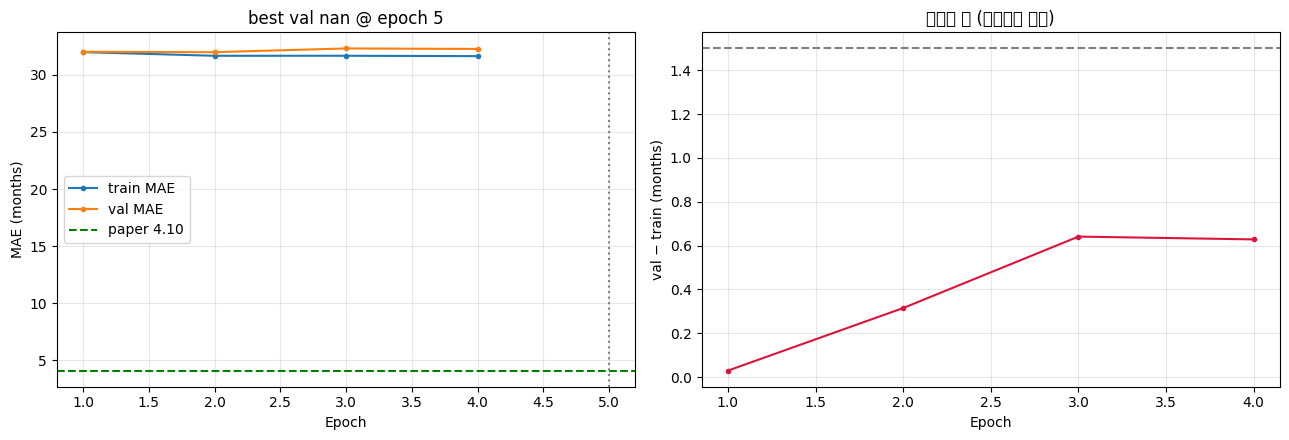

최종 갭 +nan · best 시점 갭 +nan
→ 갭이 계속 벌어지면: DROPOUT↑ / WD_HEAD↑ / AUG_STRENGTH='strong' / LR_BACKBONE↓ 순으로 조정


In [17]:
hist = json.load(open(HISTORY_JSON)) if HISTORY_JSON.exists() else history
ep   = list(range(1, len(hist["train_mae"]) + 1))
tr, va = np.array(hist["train_mae"]), np.array(hist["val_mae"])
gap  = va - tr

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, tr, "-o", ms=3, label="train MAE")
ax[0].plot(ep, va, "-o", ms=3, label="val MAE")
ax[0].axhline(4.10, ls="--", c="green", label="paper 4.10")
b = int(np.argmin(va)); ax[0].axvline(ep[b], ls=":", c="gray")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("MAE (months)")
ax[0].set_title(f"best val {va[b]:.2f} @ epoch {ep[b]}"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(ep, gap, "-o", ms=3, c="crimson"); ax[1].axhline(1.5, ls="--", c="gray")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("val − train (months)")
ax[1].set_title("과적합 갭 (커질수록 암기)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"최종 갭 {gap[-1]:+.2f} · best 시점 갭 {gap[b]:+.2f}")
print("→ 갭이 계속 벌어지면: DROPOUT↑ / WD_HEAD↑ / AUG_STRENGTH='strong' / LR_BACKBONE↓ 순으로 조정")


### 4-2. 검증셋 예측 · 산점도 · 연령대별 MAE (논문 표 6)

predict:   0%|          | 0/90 [00:00<?, ?it/s]

전체 검증 MAE 31.99 개월 · 편향 +10.31


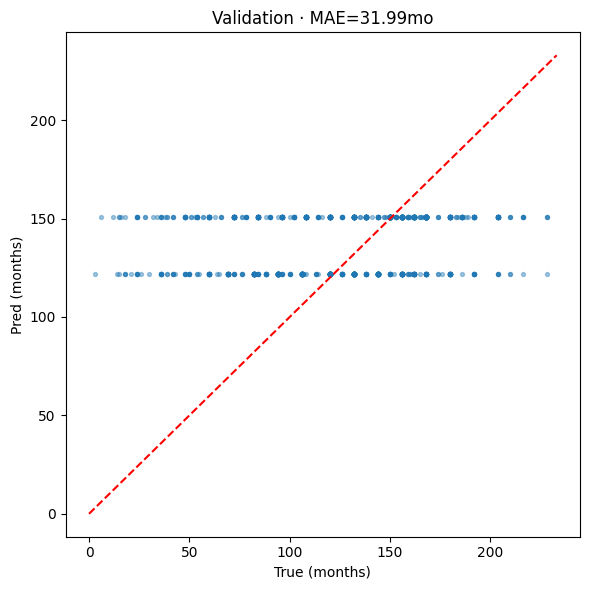

  group |    N |   MAE |   bias
   0-4y |   56 | 106.12 | +106.12
   4-8y |  286 | 57.17 | +57.17
  8-12y |  464 | 18.83 | +14.41
 12-16y |  557 | 19.51 | -19.01
   >16y |   62 | 59.54 | -59.54


In [18]:
# PART 2를 안 돌렸어도 독립 실행되도록 val_loader를 여기서 구성
_val_loader = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

preds, trues = [], []
with torch.no_grad():
    for x, g, yn, ym in tqdm(_val_loader, desc="predict"):
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=True):
            p = eval_model(x, g)
        preds.append(p.cpu()*EM_STD + EM_MEAN); trues.append(ym.squeeze(1))
preds = torch.cat(preds).numpy(); trues = torch.cat(trues).numpy()

overall = np.abs(preds - trues).mean()
print(f"전체 검증 MAE {overall:.2f} 개월 · 편향 {np.mean(preds-trues):+.2f}")

plt.figure(figsize=(6, 6)); plt.scatter(trues, preds, s=8, alpha=.4)
lim = [0, max(trues.max(), preds.max())+5]; plt.plot(lim, lim, "r--")
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Validation · MAE={overall:.2f}mo"); plt.tight_layout(); plt.show()

bins, labels = [0,48,96,144,192,10**5], ["0-4y","4-8y","8-12y","12-16y",">16y"]
print(f"{'group':>7} | {'N':>4} | {'MAE':>5} | {'bias':>6}")
for lo, hi, lab in zip(bins[:-1], bins[1:], labels):
    m = (trues>=lo) & (trues<hi)
    if m.sum(): print(f"{lab:>7} | {m.sum():>4} | {np.abs(preds[m]-trues[m]).mean():>5.2f} | {np.mean(preds[m]-trues[m]):>+6.2f}")

### 4-3. Grad-CAM (논문 그림 11)

AttributeError: 'NoneType' object has no attribute 'mean'

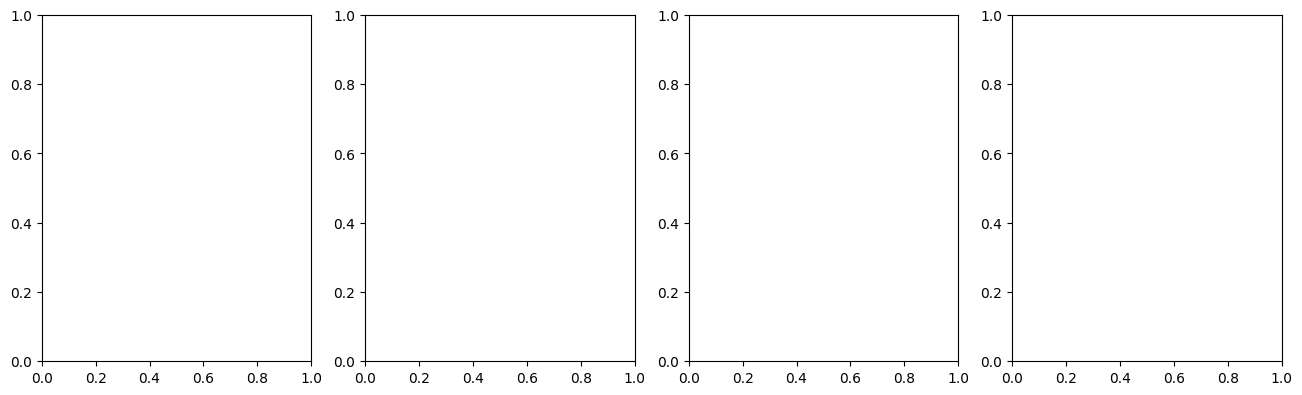

In [19]:
class GradCAM:
    '''Mixed_7c 특징 기준 Grad-CAM (회귀 출력).'''
    def __init__(self, model):
        self.model = model; self.feat = self.grad = None
        tgt = dict(model.backbone.named_modules())["Mixed_7c"]
        tgt.register_forward_hook(lambda m,i,o: setattr(self, "feat", o.detach()))
        tgt.register_full_backward_hook(lambda m,gi,go: setattr(self, "grad", go[0].detach()))
    def __call__(self, x, g):
        self.model.eval(); out = self.model(x, g); self.model.zero_grad(); out.sum().backward()
        w = self.grad.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w*self.feat).sum(1))[0]
        cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
        return cam.cpu().numpy(), out.item()

cam_engine = GradCAM(eval_model)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (_, r) in zip(axes, val_df.sample(4, random_state=1).iterrows()):
    g = imread_kr(CACHE_DIR/"val"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    x = eval_tf(np.stack([g]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[r["male"]]], dtype=torch.float32, device=device)
    cam, pn = cam_engine(x, gd); pred_month = pn*EM_STD + EM_MEAN
    heat = cv2.applyColorMap(np.uint8(255*cv2.resize(cam,(EM_IMG,EM_IMG))), cv2.COLORMAP_JET)
    over = cv2.addWeighted(cv2.cvtColor(g, cv2.COLOR_GRAY2BGR), 0.55, heat, 0.45, 0)
    ax.imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB))
    ax.set_title(f"pred {pred_month:.0f}/true {int(r.boneage)}mo"); ax.axis("off")
plt.tight_layout(); plt.show()

### 4-4. 단일 이미지 추론 (완전 독립 — best.pt + 이미지 1장이면 끝)
다른 사람은 `best.pt`만 받아 `checkpoints/`에 두고, PART 0 실행 후 이 함수만 호출하면 됩니다.

In [ ]:
def predict_bone_age(image_path, is_male, ckpt_path=BEST_CKPT):
    """원본 X-ray 경로 + 성별(True=남) → 골연령(개월). 전처리 설정을 체크포인트에서 읽어 자체 완결."""
    ck = torch.load(ckpt_path, map_location=device)
    m = build_model(ck["arch"], pretrained=False); m.load_state_dict(ck["model"]); m.eval()
    g = imread_kr(image_path, cv2.IMREAD_GRAYSCALE)
    if g is None: raise FileNotFoundError(image_path)
    pre = preprocess(g, size=ck["arch"]["IMG_SIZE"], mode=ck["arch"].get("CROP_MODE", "auto"))
    x  = eval_tf(np.stack([pre]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[float(is_male)]], dtype=torch.float32, device=device)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        pn = m(x, gd).item()
    return pn * ck["age_std"] + ck["age_mean"]

# 예시:
# months = predict_bone_age(VAL_IMG_DIR / "1386.png", is_male=True)
# print(f"예측 골연령: {months:.1f} 개월")
print("추론 함수 준비 완료 · best.pt:", BEST_CKPT)
